# Yahoo Finance Total-Return Sanity Check

This notebook compares the project's monthly total returns in NOK against a Yahoo Finance benchmark in NOK.

Project return logic:

`OurTotalReturnNOK = (Price_NOK_t + Dividend_NOK_t) / Price_NOK_t_minus_1 - 1`

Yahoo benchmark logic:

`YahooTotalReturnNOK = pct_change(YahooAdjClose_local * month_end_FX_to_NOK)`

Yahoo `Adj Close` is used as the external total-return proxy. Differences can come from vendor adjustments, dividend timing, month-end trading calendars, FX source/timing, and corporate-action handling.

## Configuration

Edit the ticker list and dates below. The default set deliberately includes examples from multiple Nordic listing currencies.

In [5]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import yfinance as yf
except ImportError as exc:
    raise ImportError('Install yfinance in this notebook kernel first: %pip install yfinance') from exc

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data').exists() and (path / 'modelling').exists() and (path / 'extraction').exists():
            return path
    raise FileNotFoundError('Could not locate project root from current notebook path.')


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / 'modelling' / 'shared'))
sys.path.insert(0, str(PROJECT_ROOT / 'extraction' / 'new_lseg_extraction'))

from helper_functions import load_prices_and_build_returns
import fx_convert_to_nok as fxconv

PRICES_NOK_CSV = PROJECT_ROOT / 'data' / 'processed_data_lseg' / 'all_stock_prices_nok.csv'
DIVIDENDS_NOK_CSV = PROJECT_ROOT / 'data' / 'processed_data_lseg' / 'dividends_monthly_nok.csv'

# Use LSEG tickers here. YAHOO_TICKER_OVERRIDES below maps LSEG share-class syntax to Yahoo syntax.
CHECK_TICKERS = [
    'EQNR.OL',
    'MOWI.OL',
    'NOVOb.CO',
    'DSV.CO',
    'VOLVb.ST',
    'AAK.ST',
    'AFAGR.HE',
    'NOKIA.HE',
]

# Leave END_MONTH = None to use the latest month available in our processed price file.
START_MONTH = '2010-01'
END_MONTH = None

# Difference threshold used in the diagnostics tables and plots.
ALERT_ABS_DIFF_BPS = 100.0

YAHOO_TICKER_OVERRIDES = {
    'NOVOb.CO': 'NOVO-B.CO',
    'VOLVb.ST': 'VOLV-B.ST',
    'ATCOa.ST': 'ATCO-A.ST',
    'ASSAb.ST': 'ASSA-B.ST',
    'ERICb.ST': 'ERIC-B.ST',
    'HMb.ST': 'HM-B.ST',
}

CURRENCY_OVERRIDES = {}

print(f'Project root: {PROJECT_ROOT}')
print(f'Checking {len(CHECK_TICKERS)} tickers from {START_MONTH} to {END_MONTH or "latest available"}.')

Project root: /Users/simenoiseth/Desktop/Equity_Quality_Under_Uncertainty
Checking 8 tickers from 2010-01 to latest available.


## Load Our Dividend-Inclusive Monthly Returns

This uses the same helper used by the main modelling pipeline, so the project-side returns are not reimplemented independently here.

In [6]:
our_returns = load_prices_and_build_returns(PRICES_NOK_CSV, dividends_csv=DIVIDENDS_NOK_CSV).copy()
our_returns = our_returns.rename(columns={'Return': 'OurTotalReturnNOK'})
our_returns['Ticker'] = our_returns['Ticker'].astype(str)
our_returns['Date'] = pd.to_datetime(our_returns['Date']) + pd.offsets.MonthEnd(0)

start_date = pd.Period(START_MONTH, freq='M').to_timestamp('M') if START_MONTH else our_returns['Date'].min()
end_date = pd.Period(END_MONTH, freq='M').to_timestamp('M') if END_MONTH else our_returns['Date'].max()

our_returns = our_returns.loc[
    our_returns['Ticker'].isin(CHECK_TICKERS)
    & (our_returns['Date'] >= start_date)
    & (our_returns['Date'] <= end_date)
].copy()

missing_from_our = sorted(set(CHECK_TICKERS) - set(our_returns['Ticker']))
print(f'Our return rows: {len(our_returns):,}')
print(f'Our date range: {our_returns["Date"].min()} to {our_returns["Date"].max()}')
if missing_from_our:
    print('Tickers missing from our return file:', missing_from_our)

display(
    our_returns.groupby('Ticker', as_index=False)
    .agg(
        Months=('Date', 'nunique'),
        FirstMonth=('Date', 'min'),
        LastMonth=('Date', 'max'),
        NonzeroDividendMonths=('Dividend', lambda s: int((s.fillna(0) != 0).sum())),
        MeanMonthlyReturn=('OurTotalReturnNOK', 'mean'),
    )
)

Our return rows: 1,560
Our date range: 2010-01-31 00:00:00 to 2026-03-31 00:00:00


,Ticker,Months,FirstMonth,LastMonth,NonzeroDividendMonths,MeanMonthlyReturn
0,AAK.ST,195,2010-01-31,2026-03-31,16,0.019678
1,AFAGR.HE,195,2010-01-31,2026-03-31,9,0.008201
2,DSV.CO,195,2010-01-31,2026-03-31,17,0.018942
3,EQNR.OL,195,2010-01-31,2026-03-31,52,0.012623
4,MOWI.OL,195,2010-01-31,2026-03-31,53,0.015266
5,NOKIA.HE,195,2010-01-31,2026-03-31,26,0.009201
6,NOVOb.CO,195,2010-01-31,2026-03-31,27,0.020877
7,VOLVb.ST,195,2010-01-31,2026-03-31,15,0.016106


## FX Helpers

Yahoo prices are local-currency adjusted prices. This cell converts those adjusted prices to NOK using the same Norges Bank FX files as the extraction converter.

In [7]:
SUFFIX_CURRENCY = {
    '.OL': 'NOK',
    '.ST': 'SEK',
    '.CO': 'DKK',
    '.HE': 'EUR',
    '.IC': 'ISK',
}


def infer_currency(ticker: str) -> str:
    if ticker in CURRENCY_OVERRIDES:
        return CURRENCY_OVERRIDES[ticker]
    for suffix, currency in SUFFIX_CURRENCY.items():
        if ticker.endswith(suffix):
            return currency
    raise ValueError(f'No currency mapping for ticker {ticker}. Add it to CURRENCY_OVERRIDES.')


def yahoo_ticker_for(lseg_ticker: str) -> str:
    if lseg_ticker in YAHOO_TICKER_OVERRIDES:
        return YAHOO_TICKER_OVERRIDES[lseg_ticker]
    match = re.match(r'^(.+?)([abAB])\.(ST|CO)$', lseg_ticker)
    if match:
        return f'{match.group(1)}-{match.group(2).upper()}.{match.group(3)}'
    return lseg_ticker


fx_daily = fxconv.load_all_fx()
fx_fallback = fxconv.load_monthly_fx_fallback(fxconv.MONTHLY_FX_FALLBACK)

month_labels = pd.period_range(start=start_date, end=end_date, freq='M').astype(str)


def monthly_fx_to_nok(currency: str, months: pd.Index | list[str]) -> pd.Series:
    months = pd.Index(pd.unique([str(m) for m in months]), name='Month')
    if currency == 'NOK':
        return pd.Series(1.0, index=months, name='FXRate')

    daily = fx_daily.get(currency)
    if daily is not None:
        rates = fxconv.get_month_end_fx(daily)
    else:
        rates = pd.Series(dtype=float)

    out = rates.reindex(months).astype(float)

    fallback = fx_fallback.get(currency)
    if fallback is not None:
        fallback_rates = fallback.set_index('date').sort_index()['rate']
        fallback_rates.index = fallback_rates.index.strftime('%Y-%m')
        out = out.fillna(fallback_rates.reindex(months))

    return out.rename('FXRate')


ticker_setup = pd.DataFrame({
    'Ticker': CHECK_TICKERS,
    'YahooTicker': [yahoo_ticker_for(t) for t in CHECK_TICKERS],
    'Currency': [infer_currency(t) for t in CHECK_TICKERS],
})
display(ticker_setup)


Loading FX rates from /Users/simenoiseth/Desktop/Equity_Quality_Under_Uncertainty/extraction/new_lseg_extraction:
  EUR: 5,369 obs from 2005-01-03 to 2026-04-30


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  USD: 5,369 obs from 2005-01-03 to 2026-04-30
  SEK: 5,369 obs from 2005-01-03 to 2026-04-30


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  DKK: 5,369 obs from 2005-01-03 to 2026-04-30
  ISK: 3,065 obs from 2005-01-03 to 2026-04-30


...

  GBP: 5,369 obs from 2005-01-03 to 2026-04-30
  PLN: 5,369 obs from 2005-01-03 to 2026-04-30


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  CAD: 5,369 obs from 2005-01-03 to 2026-04-30
  CHF: 5,369 obs from 2005-01-03 to 2026-04-30

Loaded monthly FX fallback from /Users/simenoiseth/Desktop/Equity_Quality_Under_Uncertainty/data/raw_data_lseg/fx_rates.csv: DKK, EUR, ISK, NOK, SEK


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Ticker,YahooTicker,Currency
0,EQNR.OL,EQNR.OL,NOK
1,MOWI.OL,MOWI.OL,NOK
2,NOVOb.CO,NOVO-B.CO,DKK
3,DSV.CO,DSV.CO,DKK
4,VOLVb.ST,VOLV-B.ST,SEK
5,AAK.ST,AAK.ST,SEK
6,AFAGR.HE,AFAGR.HE,EUR
7,NOKIA.HE,NOKIA.HE,EUR


## Download Yahoo Adjusted Prices and Convert to NOK

The Yahoo end date is exclusive, so the fetch window intentionally runs a bit beyond the latest requested month.

In [8]:
def normalize_yahoo_columns(df: pd.DataFrame, yahoo_ticker: str) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        if yahoo_ticker in df.columns.get_level_values(-1):
            df = df.xs(yahoo_ticker, axis=1, level=-1)
        elif yahoo_ticker in df.columns.get_level_values(0):
            df = df.xs(yahoo_ticker, axis=1, level=0)
        else:
            df = df.copy()
            df.columns = df.columns.get_level_values(0)
    return df


def fetch_yahoo_monthly_adjclose(lseg_ticker: str, yahoo_ticker: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    raw = yf.download(
        yahoo_ticker,
        start=start.strftime('%Y-%m-%d'),
        end=end.strftime('%Y-%m-%d'),
        auto_adjust=False,
        actions=False,
        progress=False,
        threads=False,
    )
    if raw.empty:
        return pd.DataFrame(columns=['Ticker', 'YahooTicker', 'Date', 'YahooAdjCloseLocal'])

    raw = normalize_yahoo_columns(raw, yahoo_ticker)
    price_col = 'Adj Close' if 'Adj Close' in raw.columns else 'Close'
    monthly = pd.to_numeric(raw[price_col], errors='coerce').dropna().resample('ME').last()
    out = monthly.rename('YahooAdjCloseLocal').reset_index()
    out['Date'] = pd.to_datetime(out['Date']) + pd.offsets.MonthEnd(0)
    out['Ticker'] = lseg_ticker
    out['YahooTicker'] = yahoo_ticker
    return out[['Ticker', 'YahooTicker', 'Date', 'YahooAdjCloseLocal']]


fetch_start = (start_date - pd.offsets.MonthEnd(2)).normalize()
fetch_end = (end_date + pd.offsets.MonthEnd(2) + pd.Timedelta(days=1)).normalize()

frames = []
for row in ticker_setup.itertuples(index=False):
    print(f'Fetching {row.Ticker} as {row.YahooTicker}...')
    frames.append(fetch_yahoo_monthly_adjclose(row.Ticker, row.YahooTicker, fetch_start, fetch_end))

yahoo_prices = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
yahoo_prices = yahoo_prices.merge(ticker_setup, on=['Ticker', 'YahooTicker'], how='left')
yahoo_prices = yahoo_prices.loc[(yahoo_prices['Date'] >= start_date) & (yahoo_prices['Date'] <= end_date)].copy()
yahoo_prices['Month'] = yahoo_prices['Date'].dt.strftime('%Y-%m')

for currency, idx in yahoo_prices.groupby('Currency').groups.items():
    rates = monthly_fx_to_nok(currency, yahoo_prices.loc[idx, 'Month'])
    yahoo_prices.loc[idx, 'FXRateToNOK'] = yahoo_prices.loc[idx, 'Month'].map(rates.to_dict())

yahoo_prices['YahooAdjCloseNOK'] = yahoo_prices['YahooAdjCloseLocal'] * yahoo_prices['FXRateToNOK']
yahoo_prices = yahoo_prices.sort_values(['Ticker', 'Date'])
yahoo_prices['YahooTotalReturnNOK'] = yahoo_prices.groupby('Ticker')['YahooAdjCloseNOK'].pct_change()

missing_yahoo = sorted(set(CHECK_TICKERS) - set(yahoo_prices['Ticker']))
print(f'Yahoo monthly rows: {len(yahoo_prices):,}')
if missing_yahoo:
    print('Tickers with no Yahoo rows:', missing_yahoo)

display(
    yahoo_prices.groupby(['Ticker', 'YahooTicker', 'Currency'], as_index=False)
    .agg(Months=('Date', 'nunique'), FirstMonth=('Date', 'min'), LastMonth=('Date', 'max'), MissingFX=('FXRateToNOK', lambda s: int(s.isna().sum())))
)

Fetching EQNR.OL as EQNR.OL...
Fetching MOWI.OL as MOWI.OL...
Fetching NOVOb.CO as NOVO-B.CO...
Fetching DSV.CO as DSV.CO...
Fetching VOLVb.ST as VOLV-B.ST...
Fetching AAK.ST as AAK.ST...
Fetching AFAGR.HE as AFAGR.HE...
Fetching NOKIA.HE as NOKIA.HE...
Yahoo monthly rows: 1,560


/var/folders/j5/cllbm9vj70d8s736swfmxvfh0000gn/T/ipykernel_58140/3547859831.py:35: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  months = pd.Index(pd.unique([str(m) for m in months]), name='Month')
/var/folders/j5/cllbm9vj70d8s736swfmxvfh0000gn/T/ipykernel_58140/3547859831.py:35: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  months = pd.Index(pd.unique([str(m) for m in months]), name='Month')
/var/folders/j5/cllbm9vj70d8s736swfmxvfh0000gn/T/ipykernel_58140/3547859831.py:35: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  months = pd.Index(pd.unique([str(m) for m in months]), name='Month')
/var/folders/j5/cllbm9vj70d8s736swfmxvfh0000gn/T/ipykernel_58140/3547859831.py:35: FutureWa

,Ticker,YahooTicker,Currency,Months,FirstMonth,LastMonth,MissingFX
0,AAK.ST,AAK.ST,SEK,195,2010-01-31,2026-03-31,0
1,AFAGR.HE,AFAGR.HE,EUR,195,2010-01-31,2026-03-31,0
2,DSV.CO,DSV.CO,DKK,195,2010-01-31,2026-03-31,0
3,EQNR.OL,EQNR.OL,NOK,195,2010-01-31,2026-03-31,0
4,MOWI.OL,MOWI.OL,NOK,195,2010-01-31,2026-03-31,0
5,NOKIA.HE,NOKIA.HE,EUR,195,2010-01-31,2026-03-31,0
6,NOVOb.CO,NOVO-B.CO,DKK,195,2010-01-31,2026-03-31,0
7,VOLVb.ST,VOLV-B.ST,SEK,195,2010-01-31,2026-03-31,0


## Compare Monthly Returns

The main diagnostics are mean absolute difference, 95th percentile absolute difference, max absolute difference, and return correlation.

In [9]:
compare_cols = [
    'Ticker', 'Date', 'OurTotalReturnNOK', 'PriceReturn', 'DividendYield', 'Dividend', 'Price', 'LagPrice',
]
yahoo_cols = ['Ticker', 'YahooTicker', 'Date', 'YahooTotalReturnNOK', 'YahooAdjCloseLocal', 'FXRateToNOK', 'YahooAdjCloseNOK']

merged = our_returns[compare_cols].merge(
    yahoo_prices[yahoo_cols],
    on=['Ticker', 'Date'],
    how='inner',
    validate='1:1',
).dropna(subset=['OurTotalReturnNOK', 'YahooTotalReturnNOK']).copy()

merged['Diff'] = merged['OurTotalReturnNOK'] - merged['YahooTotalReturnNOK']
merged['DiffBps'] = merged['Diff'] * 10_000
merged['AbsDiffBps'] = merged['DiffBps'].abs()
merged['Alert'] = merged['AbsDiffBps'] >= ALERT_ABS_DIFF_BPS

summary_rows = []
for ticker, group in merged.groupby('Ticker'):
    summary_rows.append({
        'Ticker': ticker,
        'YahooTicker': group['YahooTicker'].iloc[0],
        'MonthsCompared': len(group),
        'FirstMonth': group['Date'].min(),
        'LastMonth': group['Date'].max(),
        'Correlation': group['OurTotalReturnNOK'].corr(group['YahooTotalReturnNOK']),
        'MeanAbsDiffBps': group['AbsDiffBps'].mean(),
        'MedianAbsDiffBps': group['AbsDiffBps'].median(),
        'P95AbsDiffBps': group['AbsDiffBps'].quantile(0.95),
        'MaxAbsDiffBps': group['AbsDiffBps'].max(),
        'AlertMonths': int(group['Alert'].sum()),
        'DividendMonths': int((group['Dividend'].fillna(0) != 0).sum()),
    })

summary = pd.DataFrame(summary_rows).sort_values(['MeanAbsDiffBps', 'MaxAbsDiffBps'], ascending=False)
display(summary)

worst_months = merged.sort_values('AbsDiffBps', ascending=False).head(40)
display(worst_months[['Ticker', 'YahooTicker', 'Date', 'OurTotalReturnNOK', 'YahooTotalReturnNOK', 'DiffBps', 'Dividend', 'DividendYield', 'PriceReturn', 'FXRateToNOK']])

,Ticker,YahooTicker,MonthsCompared,FirstMonth,LastMonth,Correlation,MeanAbsDiffBps,MedianAbsDiffBps,P95AbsDiffBps,MaxAbsDiffBps,AlertMonths,DividendMonths
6,NOVOb.CO,NOVO-B.CO,194,2010-02-28,2026-03-31,0.959986,44.737826,0.000877,142.336028,1761.846627,13,27
0,AAK.ST,AAK.ST,194,2010-02-28,2026-03-31,0.955475,44.019172,0.000685,349.486329,1211.773696,13,16
4,MOWI.OL,MOWI.OL,194,2010-02-28,2026-03-31,0.993268,26.216915,0.002049,149.802497,906.424177,20,53
3,EQNR.OL,EQNR.OL,194,2010-02-28,2026-03-31,0.998887,6.458886,0.002374,16.393610,282.869199,3,52
7,VOLVb.ST,VOLV-B.ST,194,2010-02-28,2026-03-31,0.998820,6.059797,0.000790,19.888268,436.028758,3,15
5,NOKIA.HE,NOKIA.HE,194,2010-02-28,2026-03-31,0.999389,5.787016,0.001196,6.957767,447.102626,4,26
1,AFAGR.HE,AFAGR.HE,194,2010-02-28,2026-03-31,0.999913,5.013883,0.006727,1.321996,279.642900,4,9
2,DSV.CO,DSV.CO,194,2010-02-28,2026-03-31,0.999981,0.767889,0.000652,2.499776,39.651146,0,17


,Ticker,YahooTicker,Date,OurTotalReturnNOK,YahooTotalReturnNOK,DiffBps,Dividend,DividendYield,PriceReturn,FXRateToNOK
1172,NOVOb.CO,NOVO-B.CO,2010-03-31,0.300921,0.124736,1761.846627,8.140500,0.195146,0.105775,1.0785
1196,NOVOb.CO,NOVO-B.CO,2012-03-31,0.191644,0.025989,1656.550923,14.354200,0.183312,0.008332,1.0221
1208,NOVOb.CO,NOVO-B.CO,2013-03-31,0.128026,-0.035711,1637.370476,18.228600,0.181979,-0.053952,1.0028
1184,NOVOb.CO,NOVO-B.CO,2011-03-31,0.137188,0.002337,1348.513113,10.571000,0.150248,-0.013060,1.0505
4,AAK.ST,AAK.ST,2010-05-31,-0.070481,-0.191659,1211.773696,3.520275,0.141566,-0.212047,0.8250
16,AAK.ST,AAK.ST,2011-05-31,0.086923,-0.029317,1162.407111,3.974850,0.137972,-0.051049,0.8725
28,AAK.ST,AAK.ST,2012-05-31,0.102933,-0.001257,1041.893062,3.979075,0.124164,-0.021232,0.8383
796,MOWI.OL,MOWI.OL,2011-05-31,-0.220779,-0.130137,-906.424177,0.800000,0.011544,-0.232323,1.0000
40,AAK.ST,AAK.ST,2013-05-31,0.113681,0.036772,769.092545,4.678800,0.092709,0.020972,0.8871
52,AAK.ST,AAK.ST,2014-05-31,0.075880,0.007537,683.423320,5.413200,0.082019,-0.006140,0.8965


## Visual Checks

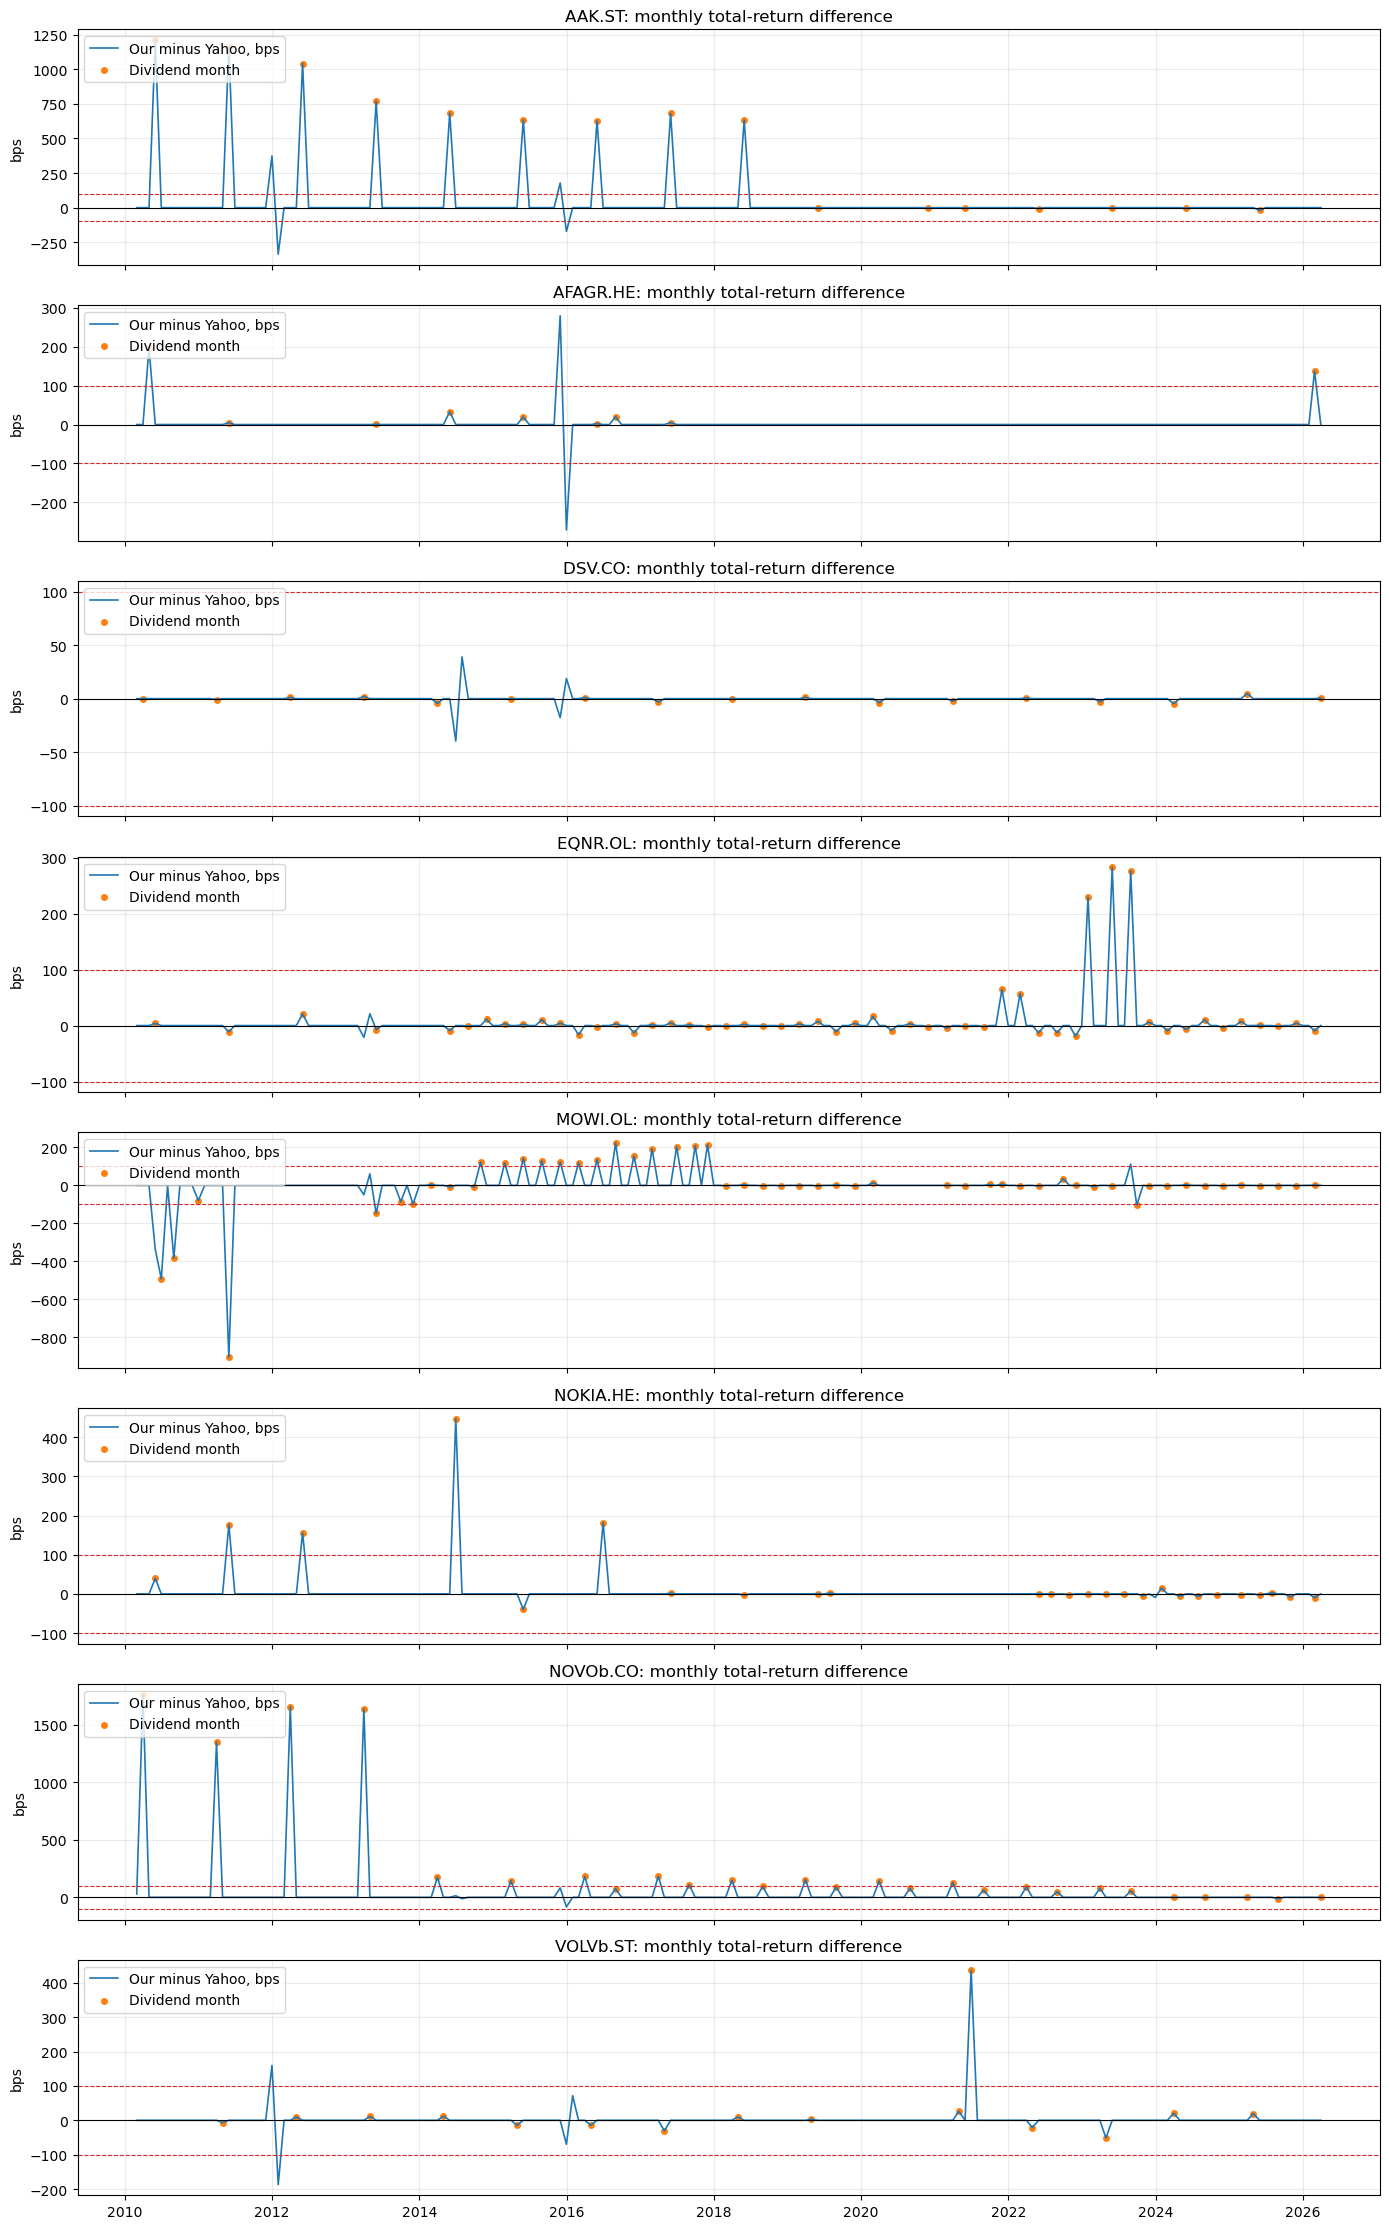

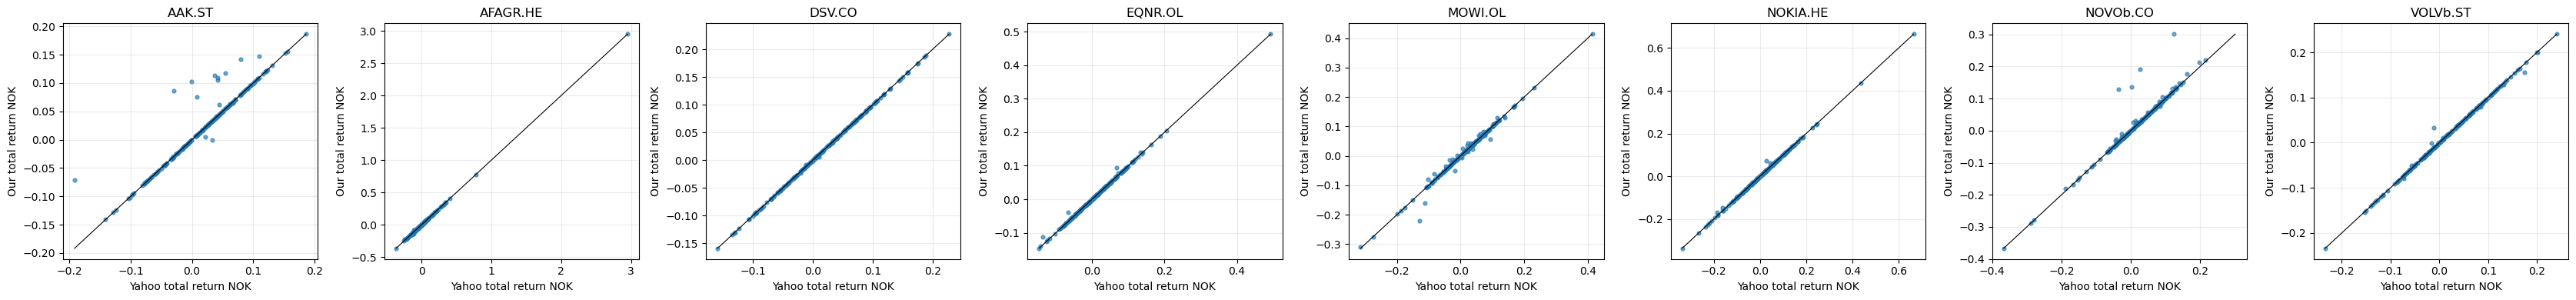

In [10]:
if merged.empty:
    print('No overlapping Yahoo/project return rows to plot.')
else:
    tickers_present = list(merged['Ticker'].drop_duplicates())
    fig, axes = plt.subplots(len(tickers_present), 1, figsize=(14, 2.8 * len(tickers_present)), sharex=True)
    if len(tickers_present) == 1:
        axes = [axes]

    for ax, ticker in zip(axes, tickers_present):
        g = merged.loc[merged['Ticker'] == ticker].sort_values('Date')
        ax.plot(g['Date'], g['DiffBps'], linewidth=1.2, label='Our minus Yahoo, bps')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axhline(ALERT_ABS_DIFF_BPS, color='tab:red', linestyle='--', linewidth=0.8)
        ax.axhline(-ALERT_ABS_DIFF_BPS, color='tab:red', linestyle='--', linewidth=0.8)
        dividend_months = g.loc[g['Dividend'].fillna(0) != 0]
        if not dividend_months.empty:
            ax.scatter(dividend_months['Date'], dividend_months['DiffBps'], color='tab:orange', s=16, label='Dividend month')
        ax.set_title(f'{ticker}: monthly total-return difference')
        ax.set_ylabel('bps')
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, len(tickers_present), figsize=(4.2 * len(tickers_present), 4), squeeze=False)
    for ax, ticker in zip(axes[0], tickers_present):
        g = merged.loc[merged['Ticker'] == ticker]
        ax.scatter(g['YahooTotalReturnNOK'], g['OurTotalReturnNOK'], s=12, alpha=0.65)
        lo = min(g['YahooTotalReturnNOK'].min(), g['OurTotalReturnNOK'].min())
        hi = max(g['YahooTotalReturnNOK'].max(), g['OurTotalReturnNOK'].max())
        ax.plot([lo, hi], [lo, hi], color='black', linewidth=0.8)
        ax.set_title(ticker)
        ax.set_xlabel('Yahoo total return NOK')
        ax.set_ylabel('Our total return NOK')
        ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

## Save Audit Outputs

This writes the merged comparison and ticker-level summary next to the notebook.

In [11]:
OUT_DIR = PROJECT_ROOT / 'manual_review' / 'stock_prices' / 'yahoo_total_return_sanity_check_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

merged.to_csv(OUT_DIR / 'monthly_total_return_comparison.csv', index=False)
summary.to_csv(OUT_DIR / 'ticker_summary.csv', index=False)
ticker_setup.to_csv(OUT_DIR / 'ticker_setup.csv', index=False)

print(f'Saved outputs to {OUT_DIR}')

Saved outputs to /Users/simenoiseth/Desktop/Equity_Quality_Under_Uncertainty/manual_review/stock_prices/yahoo_total_return_sanity_check_outputs


## Interpretation Notes

- Small monthly differences are normal because Yahoo and LSEG may use different corporate-action and adjustment conventions.
- Large differences concentrated in dividend months usually point to dividend timing, dividend currency, or split-adjustment basis.
- Large differences outside dividend months usually point to month-end price date mismatches, ticker mapping issues, or Yahoo adjustment history differences.
- The project return is the pipeline source of truth; Yahoo is only used here as an external reasonableness check.